## HEART DISEASE PREDICTION USING MACHINE LEARNING

## PROBLEM STATEMENT
Heart disease is one of the leading causes of death worldwide. Early prediction can help in timely diagnosis and treatment.
The objective of this project is to analyze patient health data and build a machine learning model to predict whether a person has heart disease.

## IMPORT LIBRARIES

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from warnings import filterwarnings
filterwarnings('ignore')

## LOAD DATASET

## DATASET DESCRIPTION
The dataset contains medical attributes of patients:

age      → Age of patient  
sex      → Gender (1 = male, 0 = female)  
cp       → Chest pain type  
restbp   → Resting blood pressure  
chol     → Cholesterol level  
fbs      → Fasting blood sugar  
restecg  → Resting ECG results  
thalach  → Maximum heart rate achieved  
exang    → Exercise induced angina  
oldpeak  → ST depression  
slope    → Slope of peak exercise  
ca       → Number of major vessels  
thal     → Thalassemia  
hd       → Target (1 = disease, 0 = no disease)

In [3]:
df = pd.read_csv(r"C:\Users\aayus\Downloads\Decision Tree-20260318T041441Z-3-001\Decision Tree\Project on Heart Disease prediction\heart-disease.csv")

In [4]:
df.columns = ['age','sex','cp','restbp','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','hd']

## BASIC EDA
1. Shape
2. Unique.
3. Descriptive Stats
4. Info - Dtypes
5. Missing Information
6. Duplicates
7. Analysis (Categorical Data and also for Numerical Data)

In [13]:
df.shape

(302, 14)

In [14]:
df.describe()

,age,sex,cp,restbp,chol,fbs,restecg,thalach,exang,oldpeak,slope,hd
count,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000,302.000000
mean,54.410596,0.678808,3.165563,131.645695,246.738411,0.145695,0.986755,149.605960,0.327815,1.035430,1.596026,0.940397
std,9.040163,0.467709,0.953612,17.612202,51.856829,0.353386,0.994916,22.912959,0.470196,1.160723,0.611939,1.229384
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.250000,0.000000,0.000000,1.000000,0.000000
50%,55.500000,1.000000,3.000000,130.000000,241.500000,0.000000,0.500000,153.000000,0.000000,0.800000,2.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000


In [29]:
display(df.dtypes)

age        float64
sex        float64
cp         float64
restbp     float64
chol       float64
fbs        float64
restecg    float64
thalach    float64
exang      float64
oldpeak    float64
slope      float64
ca         float64
thal       float64
hd           int64
dtype: object

In [6]:
if df.isnull().sum().sum() == 0:
    print("There is No Missing Information")
else:
    print("There is some Missing Informaiton")

There is No Missing Information


In [7]:
if df[df.duplicated()].shape[0] == 0:
    print("There is No Duplicated Records")
else:
    print("There is a Duplicated Records")

There is No Duplicated Records


## DATA CLEANING

In [27]:
df['ca'].unique()

array([ 3.,  2.,  0.,  1., nan])

In [28]:
df['thal'].unique()

array([ 3.,  7.,  6., nan])

In [22]:
# HANDLE WRONG VALUES
df['ca'] = df.replace('?',np.nan).ca.astype('float')

In [23]:
df['thal'] = df.replace('?',np.nan).thal.astype('float')

In [24]:
df.head()

,age,sex,cp,restbp,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,hd
0,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
1,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
2,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
3,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
4,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0


In [25]:
df['ca'] = pd.to_numeric(df['ca'])

In [26]:
df['thal'] = pd.to_numeric(df['thal'])

In [30]:
df.isnull().sum()

age        0
sex        0
cp         0
restbp     0
chol       0
fbs        0
restecg    0
thalach    0
exang      0
oldpeak    0
slope      0
ca         4
thal       2
hd         0
dtype: int64

In [31]:
df.fillna(df.median(), inplace=True)

In [32]:
df.isnull().sum()

age        0
sex        0
cp         0
restbp     0
chol       0
fbs        0
restecg    0
thalach    0
exang      0
oldpeak    0
slope      0
ca         0
thal       0
hd         0
dtype: int64

In [38]:
cols = ['sex','cp','fbs','restecg','exang','slope','ca','thal','hd']

for i in cols:
    df[i] = df[i].astype(int)

In [39]:
df.dtypes

age        float64
sex          int64
cp           int64
restbp     float64
chol       float64
fbs          int64
restecg      int64
thalach    float64
exang        int64
oldpeak    float64
slope        int64
ca           int64
thal         int64
hd           int64
dtype: object

## EXPLORATORY DATA ANALYSIS (EDA)

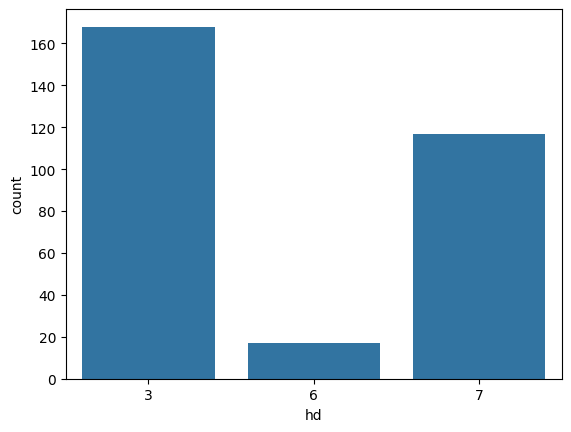

In [40]:
# Target Distribution
sns.countplot(x='hd', data=df)
plt.show()

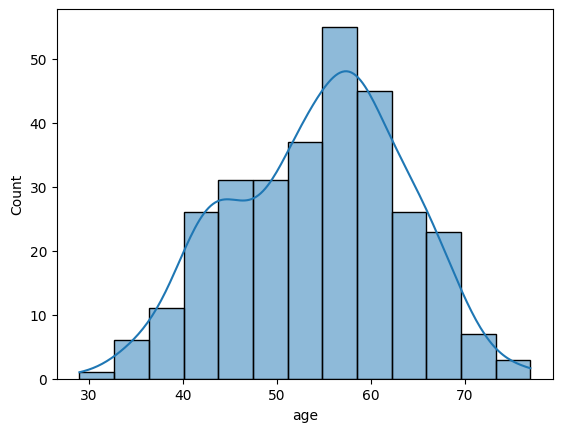

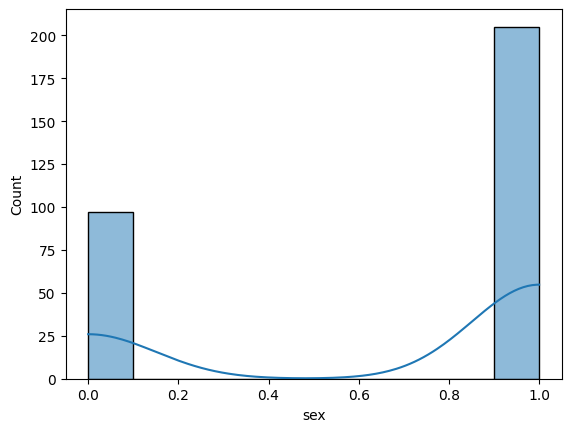

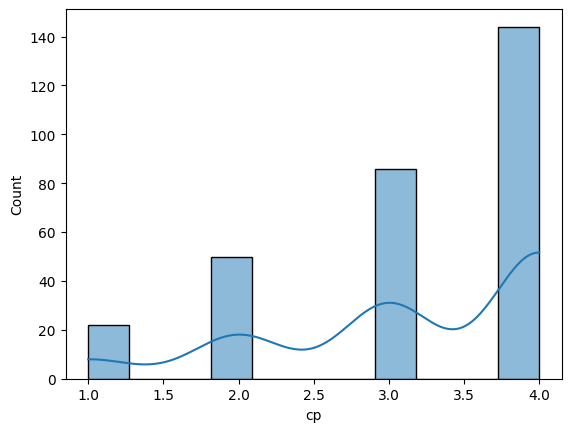

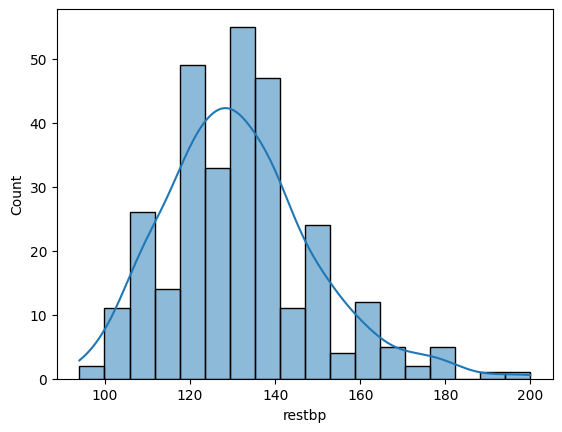

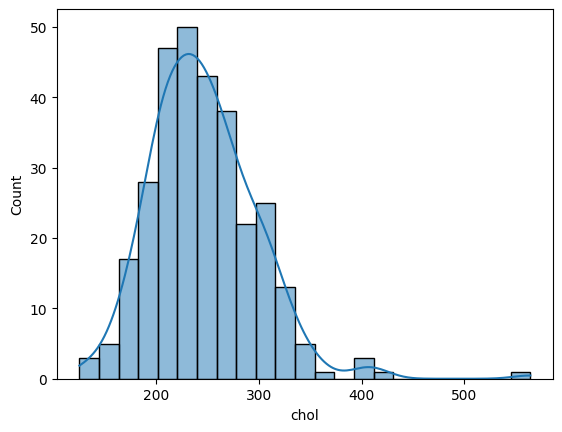

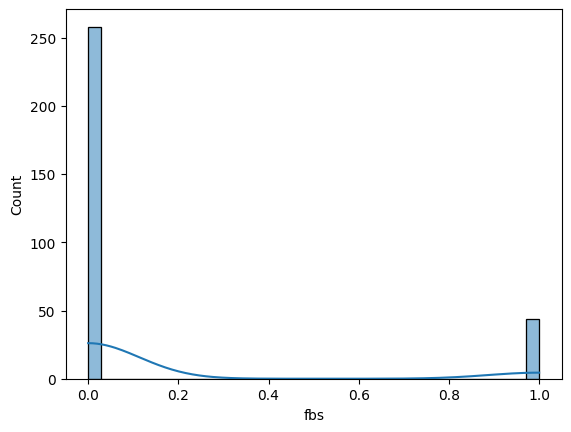

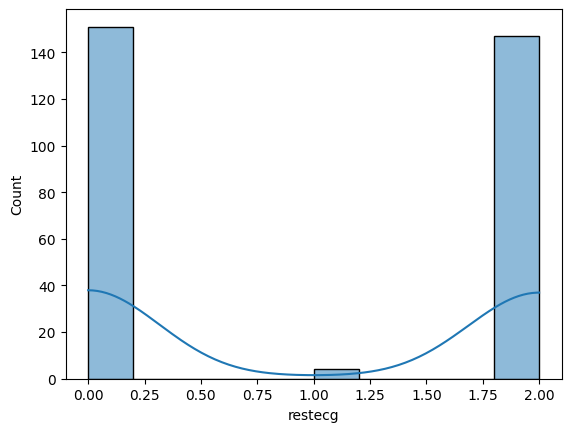

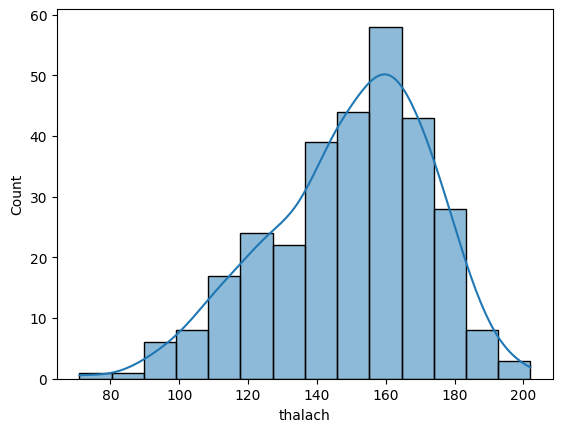

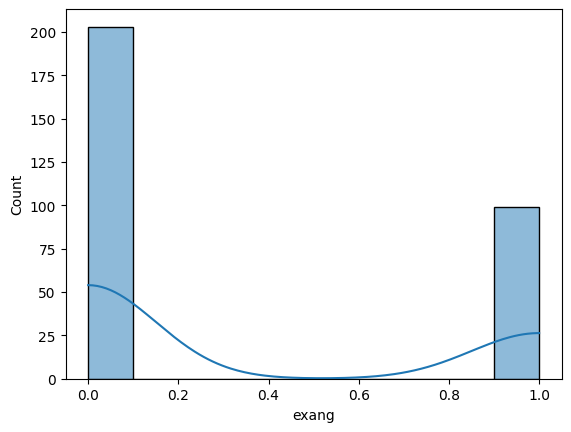

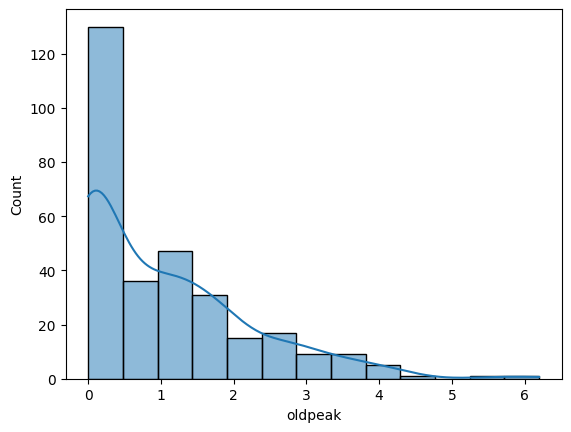

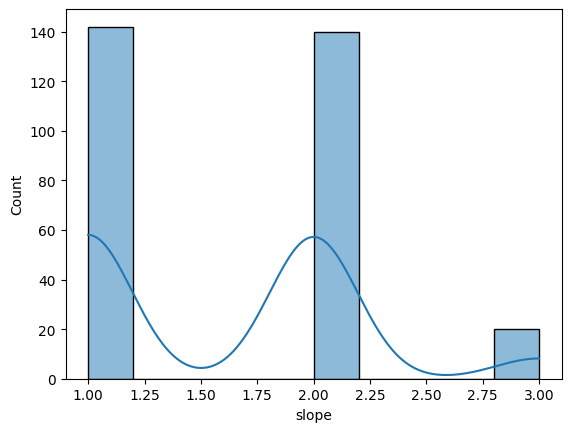

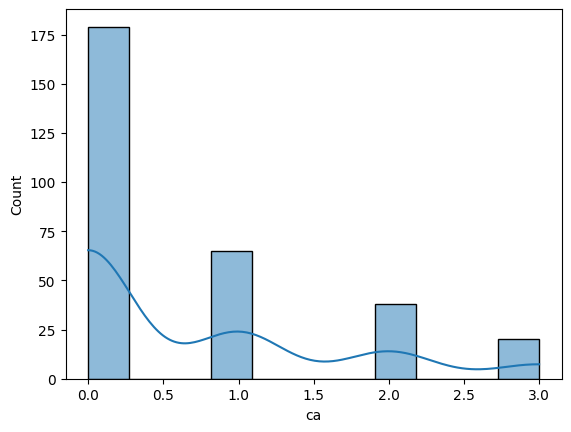

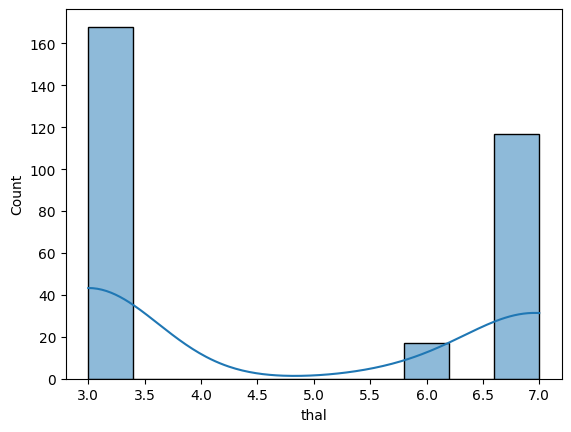

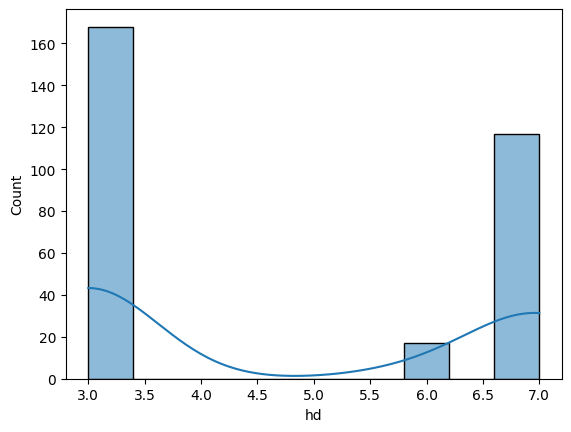

In [41]:
# Feature Distribution
for col in df.columns:
    sns.histplot(df[col], kde=True)
    plt.show()

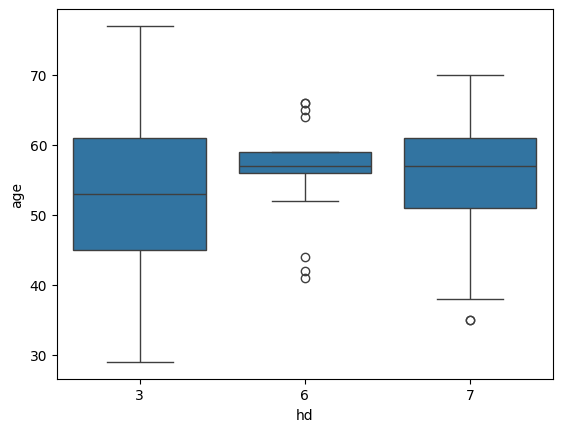

In [42]:
# Feature vs Target
sns.boxplot(x='hd', y='age', data=df)
plt.show()

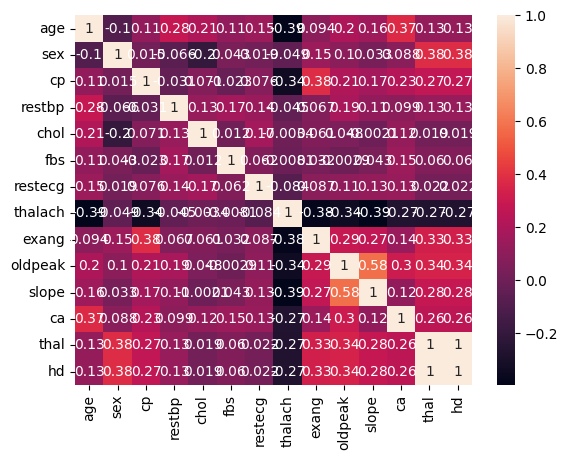

In [43]:
# Correlation
sns.heatmap(df.corr(), annot=True)
plt.show()

## FEATURE ENGINEERING
After performing Exploratory Data Analysis, the dataset was prepared for machine learning by ensuring all features were in the correct numerical format. Categorical variables such as cp, thal, and slope were already encoded numerically.

No additional feature transformation was required as the dataset was structured and clean.

## FEATURE SELECTION

In [45]:
x = df.drop('hd',axis = 1)
y = df.hd

## TRAIN TEST SPLIT

In [46]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)

## MODEL BUILDING – DECISION TREE

In [48]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


## MODEL PREDICTION

In [50]:
y_pred = model.predict(x_test)

## MODEL EVALUATION

In [42]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [43]:
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

0.5245901639344263
              precision    recall  f1-score   support

           0       0.85      0.88      0.86        32
           1       0.08      0.11      0.10         9
           2       0.50      0.12      0.20         8
           3       0.18      0.22      0.20         9
           4       0.00      0.00      0.00         3

    accuracy                           0.52        61
   macro avg       0.32      0.27      0.27        61
weighted avg       0.55      0.52      0.52        61

[[28  3  0  1  0]
 [ 4  1  1  3  0]
 [ 0  2  1  4  1]
 [ 1  4  0  2  2]
 [ 0  2  0  1  0]]


## RESULT
The model achieved 52% accuracy in predicting heart disease, with better performance for class 0